In [ ]:
##"A Comparative Analysis of Cox Proportional Hazards and Random Survival Forest for Breast Cancer Prognosis"

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
data=pd.read_csv('/content/breast_cancer_survival_dataset.csv')
data.head()

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated Grade III,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated Grade II,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated Grade II,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated Grade III,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated Grade III,Regional,41,Positive,Positive,3,1,50,Alive


In [ ]:
data.shape

(4024, 15)

In [ ]:
data.isnull().sum()

,0
Age,0
Race,0
Marital Status,0
T Stage,0
N Stage,0
6th Stage,0
Grade,19
A Stage,0
Tumor Size,0
Estrogen Status,0


In [ ]:
# Replace NaN with the specific Grade IV string
data['Grade'] = data['Grade'].fillna('Grade_Undifferentiated; anaplastic; Grade IV')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Age                     4024 non-null   int64 
 1   Race                    4024 non-null   object
 2   Marital Status          4024 non-null   object
 3   T Stage                 4024 non-null   object
 4   N Stage                 4024 non-null   object
 5   6th Stage               4024 non-null   object
 6   Grade                   4024 non-null   object
 7   A Stage                 4024 non-null   object
 8   Tumor Size              4024 non-null   int64 
 9   Estrogen Status         4024 non-null   object
 10  Progesterone Status     4024 non-null   object
 11  Regional Node Examined  4024 non-null   int64 
 12  Reginol Node Positive   4024 non-null   int64 
 13  Survival Months         4024 non-null   int64 
 14  Status                  4024 non-null   object
dtypes: i

In [ ]:
data.describe()

,Age,Tumor Size,Regional Node Examined,Reginol Node Positive,Survival Months
count,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000
mean,53.972167,30.473658,14.357107,4.158052,71.297962
std,8.963134,21.119696,8.099675,5.109331,22.921430
min,30.000000,1.000000,1.000000,1.000000,1.000000
25%,47.000000,16.000000,9.000000,1.000000,56.000000
50%,54.000000,25.000000,14.000000,2.000000,73.000000
75%,61.000000,38.000000,19.000000,5.000000,90.000000
max,69.000000,140.000000,61.000000,46.000000,107.000000


In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Clean column names
data.columns = data.columns.str.strip()

In [ ]:

# Define categorical variables
categorical_vars = [
    "Race",
    "Marital Status",
    "T Stage",
    "N Stage",
    "6th Stage",
    "Grade",
    "Estrogen Status",
    "Progesterone Status"
]

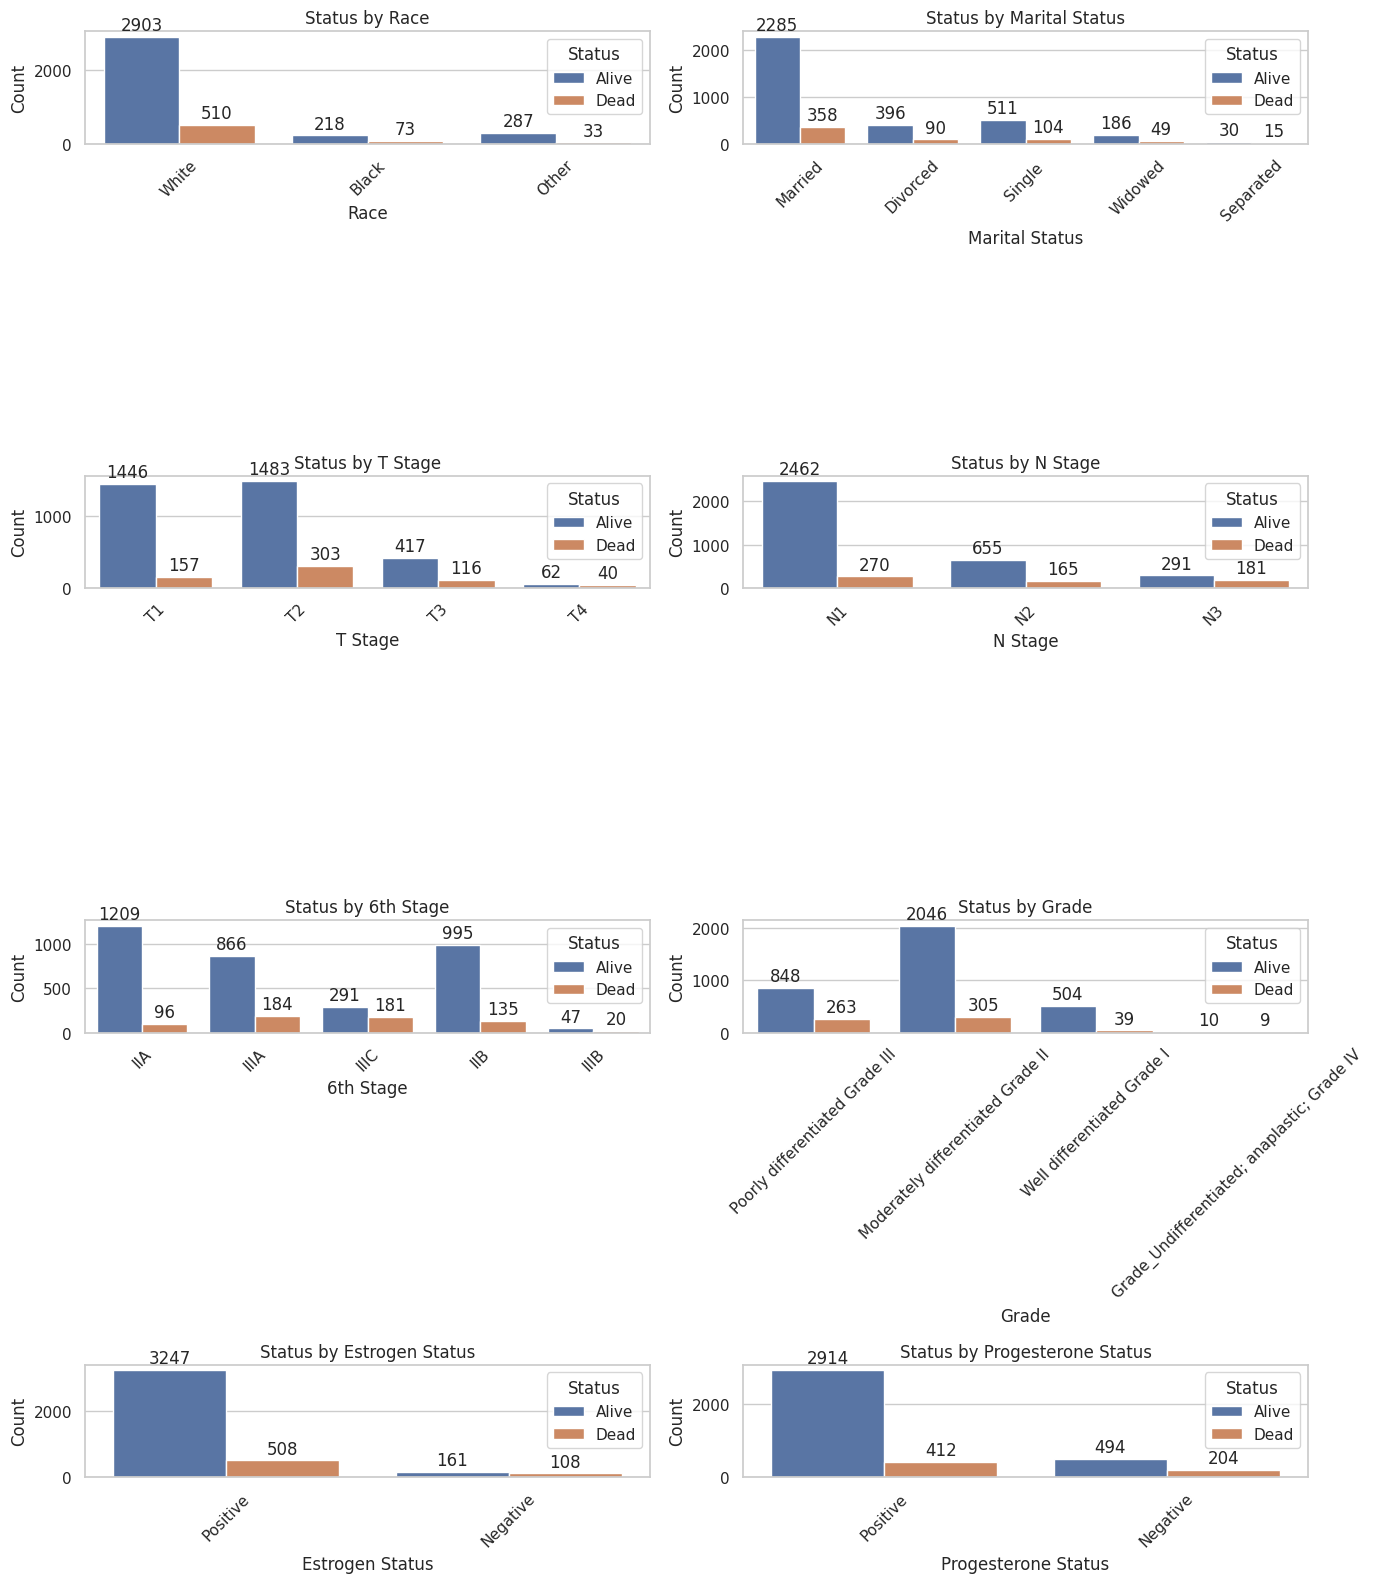

In [ ]:
# Set up plot style
sns.set(style="whitegrid")

# Set up subplots
n = len(categorical_vars)
cols = 2
rows = (n + 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 4))
axes = axes.flatten()
# Plot each categorical variable
for i, var in enumerate(categorical_vars):
    ax = axes[i]
    barplot = sns.countplot(data=data, x=var, hue="Status", ax=ax)
    ax.set_title(f"Status by {var}")
    ax.set_xlabel(var)
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=45)
    # Add count labels to bars
    for container in barplot.containers:
        barplot.bar_label(container, fmt='%d', label_type='edge', padding=2)
# Remove any unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

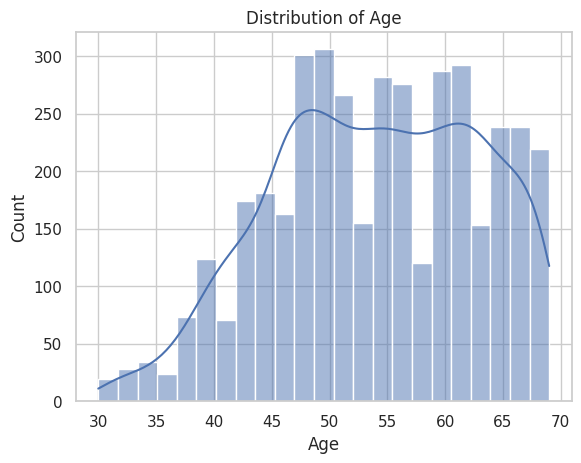

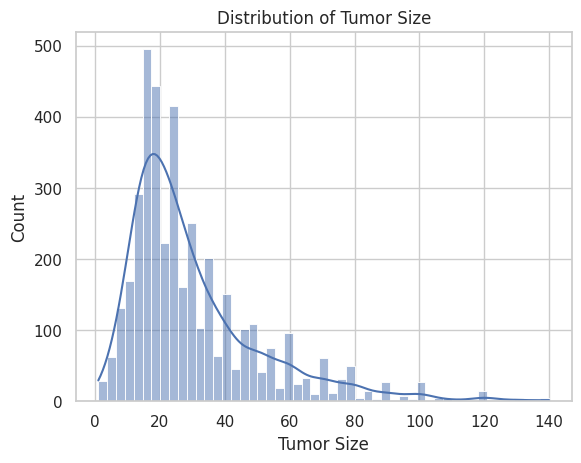

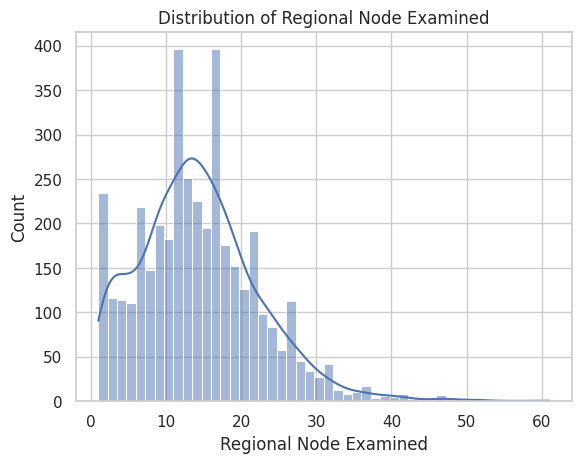

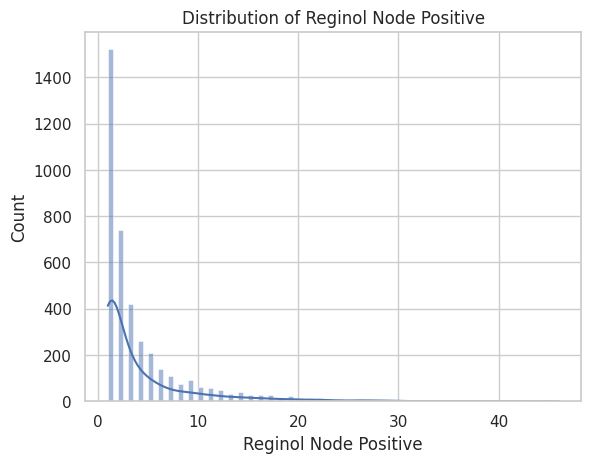

<Axes: >

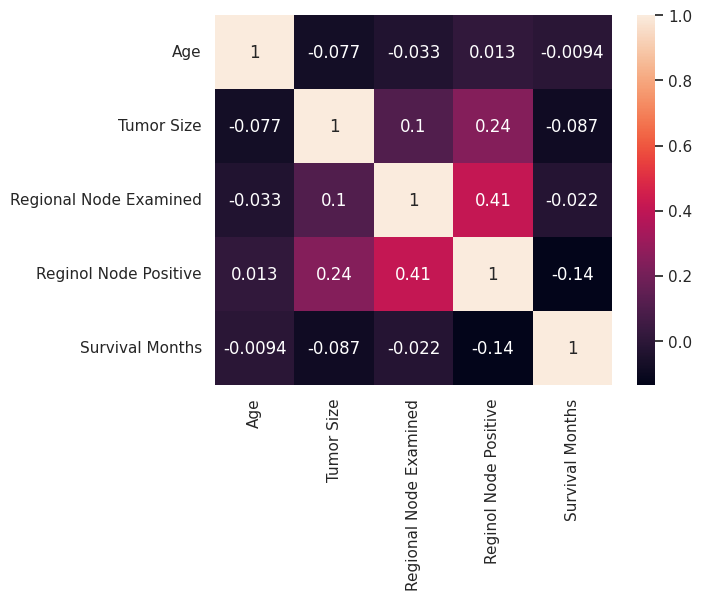

In [ ]:
# plot each numerical variable
numeric_cols = ['Age', 'Tumor Size', 'Regional Node Examined', 'Reginol Node Positive']
for col in numeric_cols:
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()
num_features=data.select_dtypes(include="number")
sns.heatmap(num_features.corr(),annot=True)



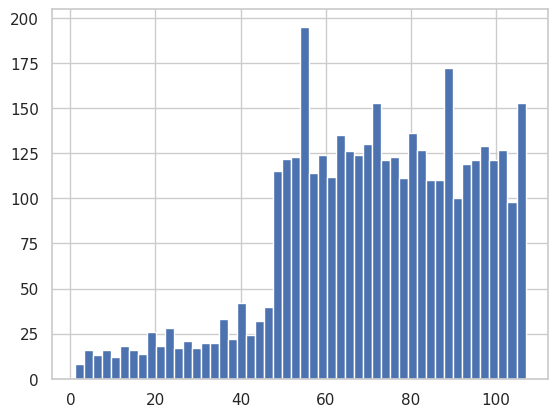

In [ ]:
T=data["Survival Months"]
E=data["Status"]
plt.hist(T,bins=50)
plt.show()


In [ ]:
data["Status"] = data["Status"].map({'Alive': 0, 'Dead': 1})
data.head()

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated Grade III,Regional,4,Positive,Positive,24,1,60,0
1,50,White,Married,T2,N2,IIIA,Moderately differentiated Grade II,Regional,35,Positive,Positive,14,5,62,0
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated Grade II,Regional,63,Positive,Positive,14,7,75,0
3,58,White,Married,T1,N1,IIA,Poorly differentiated Grade III,Regional,18,Positive,Positive,2,1,84,0
4,47,White,Married,T2,N1,IIB,Poorly differentiated Grade III,Regional,41,Positive,Positive,3,1,50,0


In [ ]:
# Install lifelines package if it's not already installed
!pip install lifelines

from lifelines import KaplanMeierFitter
from lifelines import NelsonAalenFitter

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 10.2 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=52f0359792a0d41f1a71f9bd9f40557f9bdd7c1c2fcfd9695792b471f353f09e
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


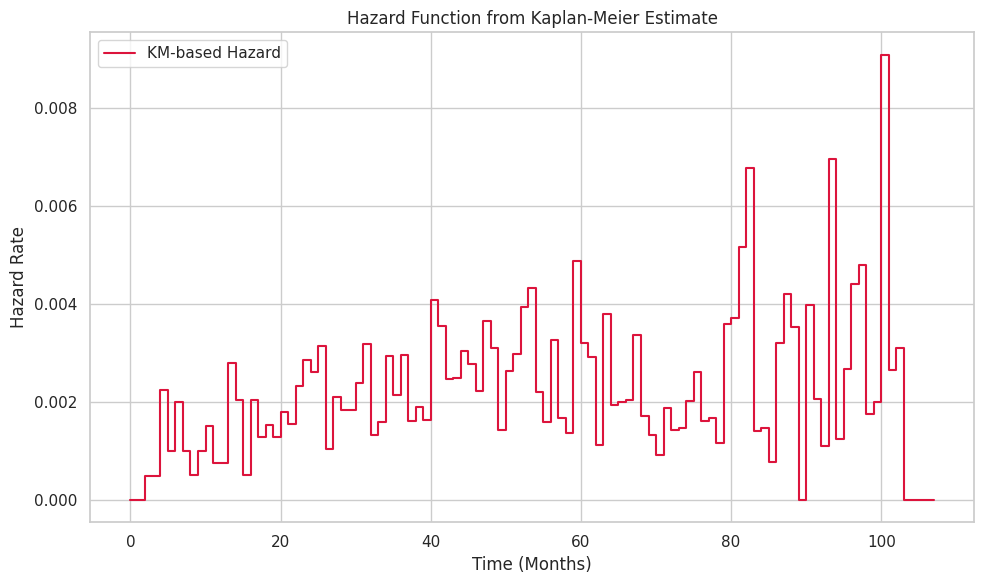

In [ ]:
# Your dataset
T = data["Survival Months"]
E = data["Status"]

# Fit Kaplan-Meier model
kmf = KaplanMeierFitter()
kmf.fit(durations=T, event_observed=E)
# Get survival function and times
S_t = kmf.survival_function_.values.flatten()
times = kmf.survival_function_.index.values

# Compute discrete hazard estimate: h(t) = -ΔS(t)/S(t)
delta_S = -np.diff(S_t, prepend=1)
hazard_estimate = delta_S / S_t

# Plot
plt.figure(figsize=(10, 6))
plt.step(times, hazard_estimate, where='post', label='KM-based Hazard', color='crimson')
plt.xlabel("Time (Months)")
plt.ylabel("Hazard Rate")
plt.title("Hazard Function from Kaplan-Meier Estimate")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

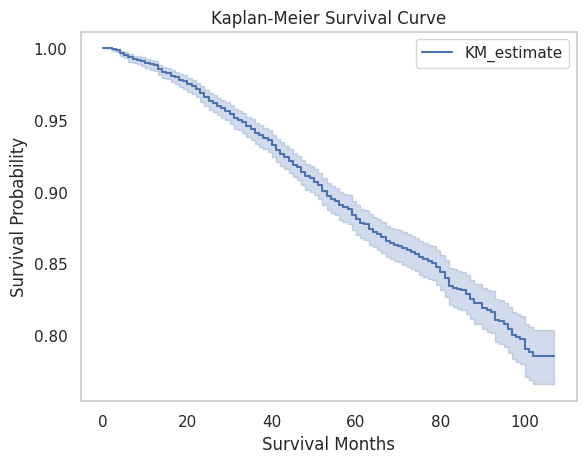

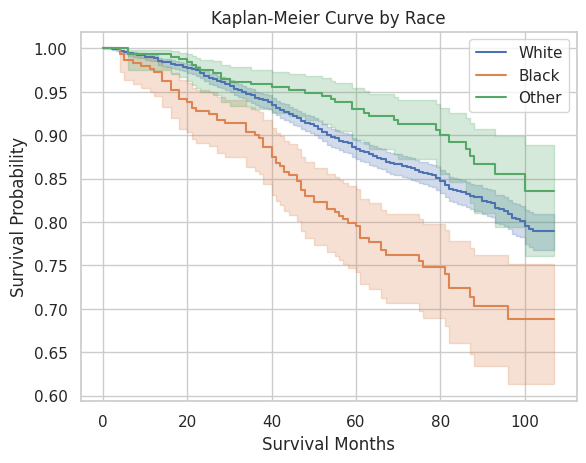

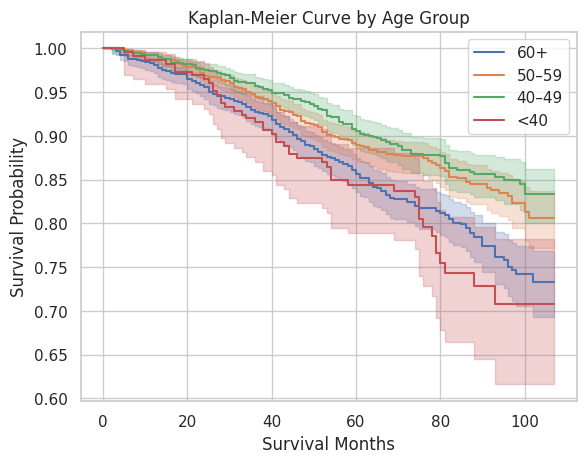

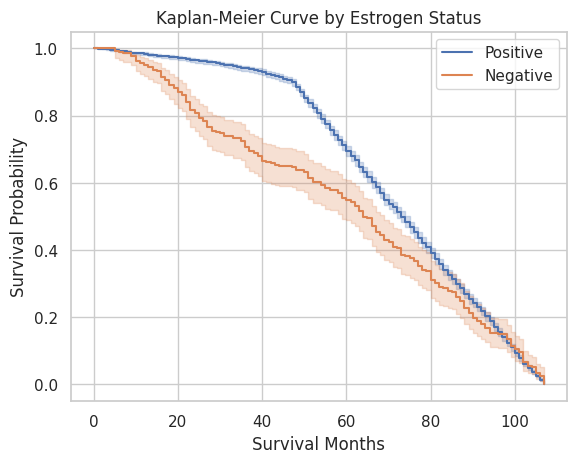

In [ ]:
# # NON PARAMETRIC MODELLING
# ### KAPLAN MEIER CURVE
import matplotlib.pyplot as plt
kmf = KaplanMeierFitter()
kmf.fit(durations=data['Survival Months'], event_observed=data['Status'])

# Plot
kmf.plot_survival_function()
plt.title('Kaplan-Meier Survival Curve')
plt.xlabel('Survival Months')
plt.ylabel('Survival Probability')
plt.grid()
plt.show()
kmf = KaplanMeierFitter()

for race in data['Race'].unique():
    mask = data['Race'] == race
    kmf.fit(data[mask]["Survival Months"], event_observed=data[mask]["Status"], label=race)
    kmf.plot()
plt.title("Kaplan-Meier Curve by Race")
plt.xlabel("Survival Months")
plt.ylabel("Survival Probability")
plt.legend()
plt.show()

bins = [0, 39, 49, 59, 100]
labels = ['<40', '40–49', '50–59', '60+']
data['Age Group'] = pd.cut(data['Age'], bins=bins, labels=labels)

for age_group in data['Age Group'].unique():
    mask = data['Age Group'] == age_group
    kmf.fit(data[mask]["Survival Months"], event_observed=data[mask]["Status"],
label=age_group)
    kmf.plot()

plt.title("Kaplan-Meier Curve by Age Group")
plt.xlabel("Survival Months")
plt.ylabel("Survival Probability")
plt.legend()
plt.show()

for est in data['Estrogen Status'].unique():
    mask = data['Estrogen Status'] == est
    kmf.fit(data[mask]["Survival Months"], event_observed=data[mask]["Survival Months"],
label=est)
    kmf.plot()

plt.title("Kaplan-Meier Curve by Estrogen Status")
plt.xlabel("Survival Months")
plt.ylabel("Survival Probability")
plt.legend()

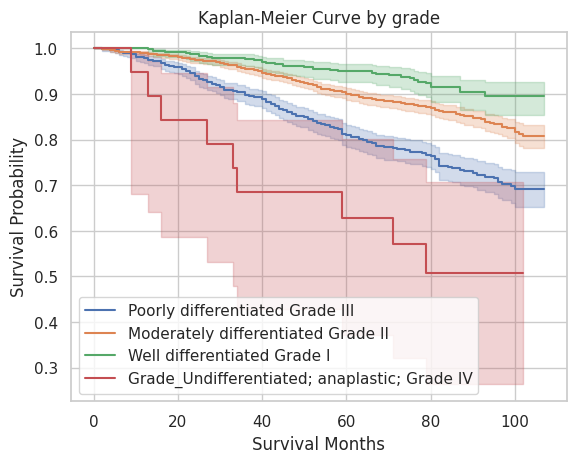

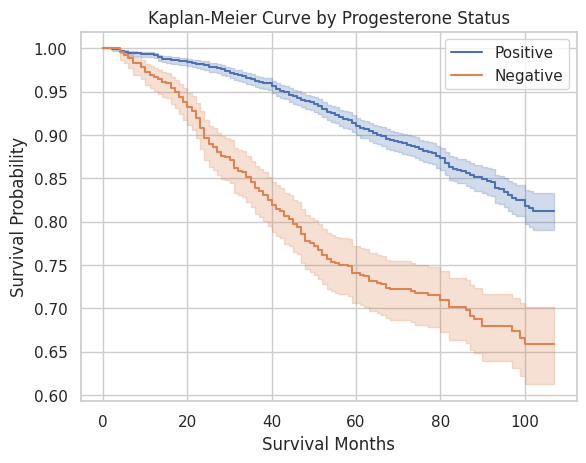

In [ ]:
data_filtered_grade = data.dropna(subset=['Grade'])
for est in data_filtered_grade['Grade'].unique():
    mask = data_filtered_grade['Grade'] == est
    kmf.fit(durations=data_filtered_grade[mask]["Survival Months"], event_observed=data_filtered_grade[mask]["Status"],
label=est)
    kmf.plot()

plt.title("Kaplan-Meier Curve by grade")
plt.xlabel("Survival Months")
plt.ylabel("Survival Probability")
plt.legend()
plt.show()

# Progesterone Status has no NaNs, so no need to filter data again
for prog in data['Progesterone Status'].unique():
    mask = data['Progesterone Status'] == prog
    kmf.fit(durations=data[mask]["Survival Months"], event_observed=data[mask]["Status"],
label=prog)
    kmf.plot()

plt.title("Kaplan-Meier Curve by Progesterone Status")
plt.xlabel("Survival Months")
plt.ylabel("Survival Probability")
plt.legend()
plt.show()

### Log-Rank Test

The log-rank test is a non-parametric hypothesis test used to compare the survival distributions of two or more groups. It tests the null hypothesis that there is no difference in survival between the groups.

In [ ]:
from lifelines.statistics import multivariate_logrank_test

# List of categorical variables to test
logrank_categorical_vars = [
    "Race",
    "Marital Status",
    "T Stage",
    "N Stage",
    "6th Stage",
    "Grade",
    "Estrogen Status",
    "Progesterone Status",
    "Age Group"
]

for var in logrank_categorical_vars:
    # Ensure there are at least two unique groups to compare
    if data[var].nunique() > 1:
        # The multivariate_logrank_test expects single columns for durations, groups, and events
        # not lists of Series. We pass the full Series from the DataFrame.
        results = multivariate_logrank_test(event_durations=data["Survival Months"],
                                          groups=data[var],
                                          event_observed=data["Status"])

        print(f"\n--- Log-Rank Test for {var} ---")
        results.print_summary()
    else:
        print(f"\n--- Skipping Log-Rank Test for {var} (only one unique group) ---")


--- Log-Rank Test for Race ---



--- Log-Rank Test for Marital Status ---



--- Log-Rank Test for T Stage ---



--- Log-Rank Test for N Stage ---



--- Log-Rank Test for 6th Stage ---



--- Log-Rank Test for Grade ---



--- Log-Rank Test for Estrogen Status ---



--- Log-Rank Test for Progesterone Status ---



--- Log-Rank Test for Age Group ---


In [ ]:
# # Semi-parametric modeling (cox proportional hazard model)

# ### checking assumptions of cox proportional hazard model
from lifelines import CoxPHFitter
cph=CoxPHFitter()

df_cox = data[['Survival Months', 'Status', 'Age', 'Tumor Size', 'Race', 'Marital Status', 'T Stage', 'N Stage', 'Grade', 'Estrogen Status', 'Progesterone Status']]
df_cox = pd.get_dummies(df_cox, drop_first=True)
cph.fit(df_cox, duration_col='Survival Months', event_col='Status')
cph.check_assumptions(df_cox,p_value_threshold=0.05)


The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'Estrogen Status_Positive' failed the non-proportional test: p-value is 0.0014.

   Advice: with so few unique values (only 2), you can include `strata=['Estrogen Status_Positive',
...]` in the call in `.fit`. See documentation in link [E] below.

2. Variable 'Progesterone Status_Positive' failed the non-proportional test: p-value is 0.0016.

   Advice: with so few unique values (only 2), you can include `strata=['Progesterone
Status_Positive', ...]` in the call in `.fit`. See documentation in link [E] below.

---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Introduce-time-varying-covariates
[D]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20h

[]

In [ ]:
df_cox = data[['Survival Months', 'Status', 'Age', 'Tumor Size', 'Race', 'Marital Status', 'T Stage', 'N Stage', 'Grade']]
df_cox = pd.get_dummies(df_cox, drop_first=True)
cph.fit(df_cox, duration_col='Survival Months', event_col='Status')
cph.check_assumptions(df_cox,p_value_threshold=0.05)

Proportional hazard assumption looks okay.


[]

In [ ]:
df_cox = data[['Survival Months', 'Status', 'Age', 'Tumor Size', 'Race', 'Marital Status', 'T Stage', 'N Stage', 'Grade']]
df_cox = pd.get_dummies(df_cox, drop_first=True)
cph.fit(df_cox, duration_col='Survival Months', event_col='Status')

<lifelines.CoxPHFitter: fitted with 4024 total observations, 3408 right-censored observations>

<lifelines.CoxPHFitter: fitted with 4024 total observations, 3408 right-censored observations>
             duration col = 'Survival Months'
                event col = 'Status'
      baseline estimation = breslow
   number of observations = 4024
number of events observed = 616
   partial log-likelihood = -4731.35
         time fit was run = 2026-04-30 16:44:04 UTC

---
                                          coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                 
Age                                       0.02      1.02      0.00            0.01            0.03                1.01                1.03
Tumor Size                                0.00      1.00      0.00           -0.00            0.01                1.00                1.01
Race_Other                               -0.75      0.47      0.21           -1.17           -0.33                0.31                0.72
Race_White                               -0.41      0.66      0.13           -0.66           -0.16                0.52                0.85
Marital Status_Married                   -0.18      0.84      0.12           -0.41            0.05                0.66                1.05
Marital Status_Separated                  0.71      2.03      0.29            0.15            1.27                1.16                3.56
Marital Status_Single                    -0.01      0.99      0.15           -0.30            0.27                0.74                1.31
Marital Status_Widowed                    0.00      1.00      0.18           -0.35            0.36                0.70                1.43
T Stage_T2                                0.32      1.38      0.11            0.10            0.54                1.10                1.72
T Stage_T3                                0.36      1.44      0.22           -0.07            0.80                0.93                2.22
T Stage_T4                                0.75      2.13      0.24            0.29            1.22                1.33                3.39
N Stage_N2                                0.61      1.85      0.10            0.42            0.81                1.52                2.25
N Stage_N3                                1.21      3.35      0.10            1.01            1.41                2.74                4.10
Grade_Moderately differentiated Grade II -1.13      0.32      0.35           -1.81           -0.44                0.16                0.64
Grade_Poorly differentiated Grade III    -0.62      0.54      0.35           -1.30            0.07                0.27                1.07
Grade_Well differentiated Grade I        -1.59      0.20      0.38           -2.34           -0.84                0.10                0.43

                                          cmp to     z      p  -log2(p)
covariate                                                              
Age                                         0.00  4.18 <0.005     15.06
Tumor Size                                  0.00  0.77   0.44      1.18
Race_Other                                  0.00 -3.52 <0.005     11.19
Race_White                                  0.00 -3.19 <0.005      9.47
Marital Status_Married                      0.00 -1.51   0.13      2.93
Marital Status_Separated                    0.00  2.48   0.01      6.25
Marital Status_Single                       0.00 -0.09   0.93      0.11
Marital Status_Widowed                      0.00  0.02   0.99      0.02
T Stage_T2                                  0.00  2.83 <0.005      7.73
T Stage_T3                                  0.00  1.64   0.10      3.32
T Stage_T4                                  0.00  3.17 <0.005      9.37
N Stage_N2                                  0.00  6.06 <0.005     29.49
N Stage_N3                                  0.00 11.77 <0.005    103.88
Grade_Moderately differentiated Grade II    

<Axes: >

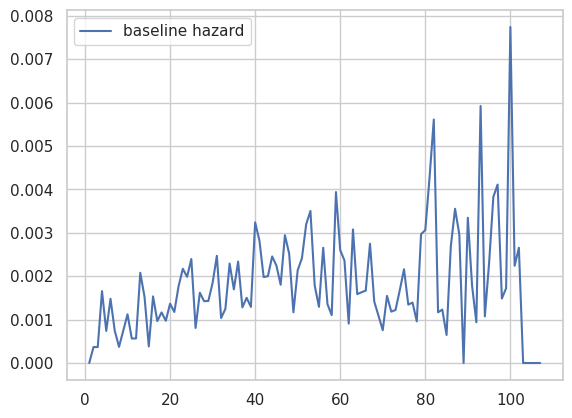

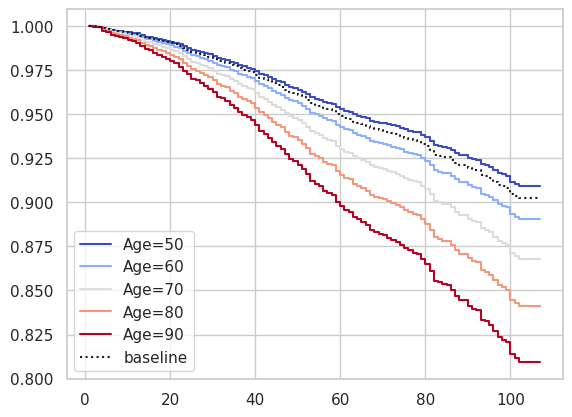

In [ ]:
# Print summary
cph.print_summary()
cph.baseline_hazard_.plot()
cph.plot_partial_effects_on_outcome(covariates='Age',
                                   values=[50,60,70,80,90],
                                   cmap='coolwarm')

covariate
Grade_Well differentiated Grade I           1.590988
N Stage_N3                                  1.208687
Grade_Moderately differentiated Grade II    1.126242
T Stage_T4                                  0.754555
Race_Other                                  0.752315
Marital Status_Separated                    0.709029
Grade_Poorly differentiated Grade III       0.615308
N Stage_N2                                  0.613960
Race_White                                  0.410403
T Stage_T3                                  0.362897
T Stage_T2                                  0.321410
Marital Status_Married                      0.179732
Age                                         0.020027
Marital Status_Single                       0.013580
Marital Status_Widowed                      0.003180
Tumor Size                                  0.002453
Name: coef, dtype: float64


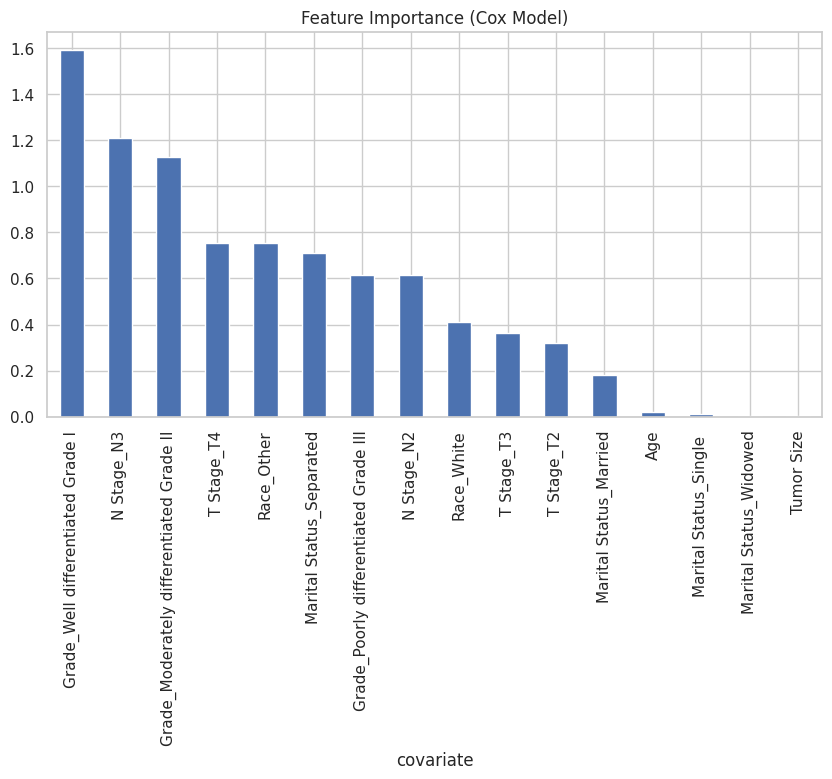

In [ ]:
import numpy as np

# Hazard ratio importance
cox_importance = pd.Series(
    np.abs(cph.params_),
    index=cph.params_.index
).sort_values(ascending=False)

print(cox_importance)

# Plot
cox_importance.plot(kind='bar', figsize=(10,5))
plt.title("Feature Importance (Cox Model)")
plt.show()

In [ ]:
c_index = cph.concordance_index_
print("Cox Model C-index:", c_index)

Cox Model C-index: 0.7148010558770072


### Random Survival Forest Analysis
Random Survival Forest is a non-parametric alternative to Cox Proportional Hazards that can capture complex non-linear relationships and interactions without assuming proportional hazards.

In [ ]:
!pip install scikit-survival

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 94.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 18.6 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


RSF C-index: 0.7713073612292969


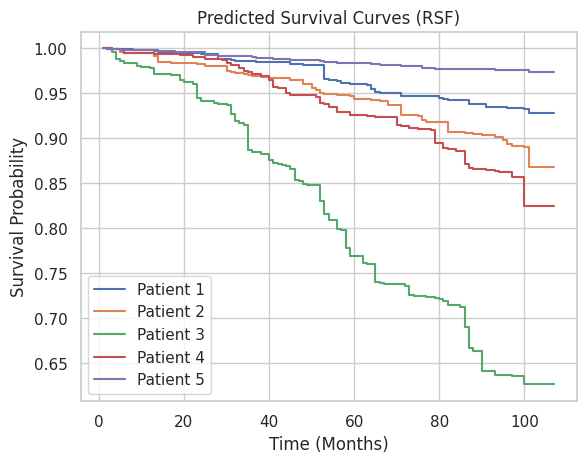

In [ ]:
import numpy as np
import pandas as pd
from sksurv.ensemble import RandomSurvivalForest
from sklearn.model_selection import train_test_split

# -------------------------------
# 1. Create survival object (event, time)
# -------------------------------
y = np.array(
    [(bool(s), t) for s, t in zip(data['Status'], data['Survival Months'])],
    dtype=[('event', '?'), ('time', '<f8')]
)

# -------------------------------
# 2. Select features
# -------------------------------
X = data[
    [
        'Age', 'Race', 'Marital Status', 'T Stage', 'N Stage', '6th Stage',
        'Grade', 'A Stage', 'Tumor Size', 'Estrogen Status',
        'Progesterone Status', 'Regional Node Examined', 'Reginol Node Positive'
    ]
]

# -------------------------------
# 3. Convert categorical variables
# -------------------------------
X = pd.get_dummies(X, drop_first=True)

# -------------------------------
# 4. Train-test split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# 5. Train RSF model
# -------------------------------
rsf = RandomSurvivalForest(
    n_estimators=100,
    min_samples_split=10,
    min_samples_leaf=15,
    random_state=42
)

rsf.fit(X_train, y_train)

# -------------------------------
# 6. Model performance (C-index)
# -------------------------------
c_index_rsf = rsf.score(X_test, y_test)
print("RSF C-index:", c_index_rsf)


# -------------------------------
# 8. Survival curves (5 patients)
# -------------------------------
surv_funcs = rsf.predict_survival_function(X_test.iloc[:5])

plt.figure()

for i, fn in enumerate(surv_funcs):
    plt.step(fn.x, fn.y, where="post", label=f"Patient {i+1}")

plt.xlabel("Time (Months)")
plt.ylabel("Survival Probability")
plt.title("Predicted Survival Curves (RSF)")
plt.legend()
plt.show()

### Feature Importance for Random Survival Forest
To understand which features are most influential in our survival model, we will calculate the **Permutation Feature Importance**. This method measures the decrease in the model's score (C-index) when a single feature value is randomly shuffled.

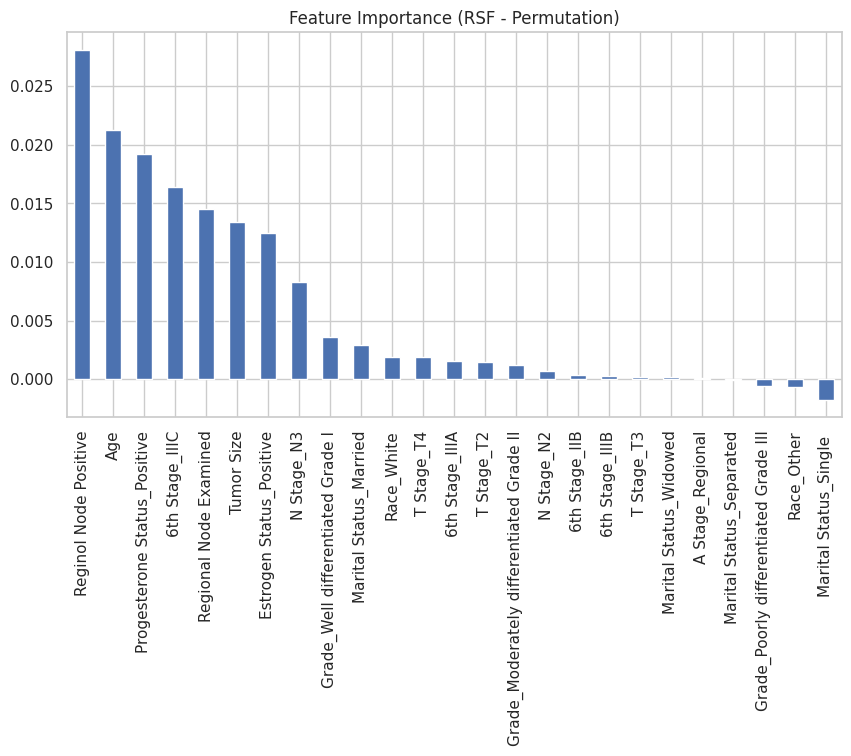

In [ ]:
from sklearn.inspection import permutation_importance

# Compute permutation importance
result = permutation_importance(
    rsf, X_test, y_test,
    n_repeats=10,
    random_state=42
)

# Convert to pandas series
importance = pd.Series(result.importances_mean, index=X.columns)
importance = importance.sort_values(ascending=False)

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
importance.plot(kind='bar')
plt.title("Feature Importance (RSF - Permutation)")
plt.show()

### Model Comparison: Cox PH vs. Random Survival Forest
We compare the Concordance Index (C-index) of both models on the test set. For the Cox model, we must use the same features and dummified format used for the RSF test set.

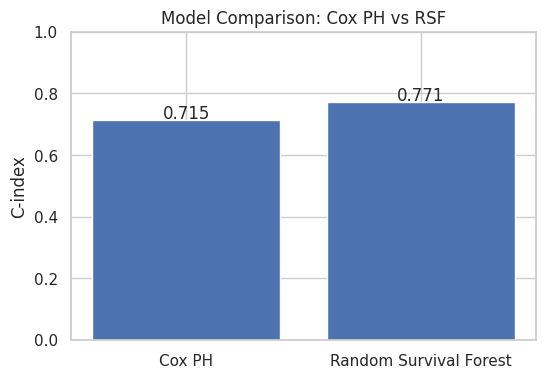

In [ ]:
# Store your C-index values
results = pd.DataFrame({
    "Model": ["Cox PH", "Random Survival Forest"],
    "C-index": [c_index,c_index_rsf]
})

# Plot bar chart
plt.figure(figsize=(6,4))
plt.bar(results["Model"], results["C-index"])

# Labels and title
plt.ylabel("C-index")
plt.title("Model Comparison: Cox PH vs RSF")

# Show values on top
for i, v in enumerate(results["C-index"]):
    plt.text(i, v + 0.005, f"{v:.3f}", ha='center')

plt.ylim(0, 1)
plt.show()